# IsyaraLive — Training Model Pengenalan Gestur BISINDO (Versi Perbaikan Final)

Ringkasan seluruh perbaikan sepanjang proses debugging:
1. **Split berdasarkan video (group split)**, bukan sequence — mencegah data leakage dari sliding window yang overlap.
2. **3-way split (train/val/test)** — val untuk pilih model terbaik, test cuma dibuka sekali di akhir.
3. **Cache landmark per frame** (bukan per window) + `cap.grab()/retrieve()` + skip frame mentah (lihat poin 12 soal `TARGET_TRAIN_FPS`) — jauh lebih cepat dari versi awal.
4. **Checkpoint & resume otomatis** ke Google Drive tiap 100 video — aman dari disconnect Colab.
5. **Dedup lintas dataset** berdasarkan hash file — mencegah video yang sama (re-upload berbeda nama) dihitung dua kali.
6. **MAX_VIDEOS_PER_GROUP** — batasi video per (kata, subjek) supaya tidak membengkak ke puluhan ribu video.
7. **Pembersihan label "subjek N"** yang tercampur ke label kata (bug dari versi lama) — video yang tercemar otomatis diproses ulang.
8. **Pembersihan shape tidak seragam** (ragged array) sebelum training.
9. **Normalisasi landmark** (relatif wrist + scale-invariant) — perbaikan utama untuk masalah akurasi 0% di leave-one-subject-out, karena sebelumnya koordinat masih absolut terhadap frame kamera, sehingga model gagal total saat framing kamera subjek baru berbeda.
10. **Leave-one-subject-out evaluation** dengan diagnostik NaN/gradient clipping/collapse detection.
11. **Ekstraksi landmark pakai letterbox, bukan resize paksa ke 640x640** — resize paksa meregangkan rasio aspek tangan secara berbeda untuk x vs y, dan peregangan itu TIDAK hilang oleh normalisasi wrist-relative + scale (poin 9), karena normalisasi itu cuma seragam, sedangkan peregangannya anisotropik. Ini juga membuat jalur ekstraksi latih tidak cocok dengan jalur deteksi di device (MediaPipe di Flutter memberi frame rasio asli + letterbox internal, bukan diregangkan). Sekarang KEDUANYA (notebook & backend) memakai fungsi letterbox yang sama persis.
12. **Ekstraksi landmark dinormalisasi ke FPS TETAP (bukan skip-per-frame-mentah)** — sebelumnya `RAW_FRAME_SKIP=2` men-skip frame MENTAH secara konstan, jadi rentang waktu 15 frame yang dilihat model beda-beda tergantung fps asli tiap video sumber (bisa 24/25/30 fps campur dari 3 dataset Kaggle) — tidak pernah benar-benar terukur/konsisten. Sekarang tiap video dijadikan sama persis `TARGET_TRAIN_FPS=10` lewat `frame_skip = round(video_fps / TARGET_TRAIN_FPS)` per video, jadi 15 frame SELALU merepresentasikan ~1,5 detik gerakan, siapa pun sumber videonya — dan aplikasi WAJIB mengirim landmark persis di 10 fps supaya buffer 15-frame di server merepresentasikan rentang waktu yang SAMA seperti saat training (kalau beda, model melihat rentang gerakan yang tidak sesuai pelatihan dan prediksinya bisa salah secara senyap).

## 1. Install library

In [1]:
!pip install mediapipe opencv-python-headless kaggle tqdm -q
print("✅ Install done")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.9/37.9 MB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 4.1 MB/s eta 0:00:00
✅ Install done


## 2. Download dataset dari Kaggle (xazhurea/test500)

In [2]:
from google.colab import files
print("Upload kaggle.json:")
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d xazhurea/test500 -p /content/xazhurea_raw/ -q
print("✅ Download done")

Upload kaggle.json:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/xazhurea/test500
License(s): unknown
✅ Download done


In [3]:
import zipfile, os

with zipfile.ZipFile("/content/xazhurea_raw/test500.zip", "r") as z:
    z.extractall("/content/xazhurea/")
print("✅ Extract done")

for category in sorted(os.listdir("/content/xazhurea/")):
    print(f"📁 {category}")

✅ Extract done
📁 5W+1H
📁 Kata Ganti Orang
📁 Kata Kerja
📁 Kata Lainnya
📁 Kata Sifat


## 3. Setup MediaPipe Hand Landmarker

In [4]:
import mediapipe as mp
import urllib.request
import os

os.makedirs("models", exist_ok=True)
if not os.path.exists("models/hand_landmarker.task"):
    print("Downloading MediaPipe model...")
    urllib.request.urlretrieve(
        "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task",
        "models/hand_landmarker.task"
    )

BaseOptions = mp.tasks.BaseOptions
HandLandmarker = mp.tasks.vision.HandLandmarker
HandLandmarkerOptions = mp.tasks.vision.HandLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

options = HandLandmarkerOptions(
    base_options=BaseOptions(model_asset_path="models/hand_landmarker.task"),
    running_mode=VisionRunningMode.IMAGE,
    num_hands=1,
    min_hand_detection_confidence=0.3,
    min_hand_presence_confidence=0.3,
    min_tracking_confidence=0.3
)
print("✅ MediaPipe ready")

✅ MediaPipe ready


## 4a. Download dataset tambahan (5 subjek + 40 kata)
- `aridone/dataset-bisindo-40-kata-5-subjek` — 5 subjek berbeda, struktur `kata/subjek N/sN-kata-n.mp4`
- `anggiyohanespardede/bisindo-40-kata-mp4` — struktur `raw_video/kata/BISINDO_kata_NNN.mp4` (subjek tidak diketahui dari nama file)

In [5]:
import zipfile, os

!kaggle datasets download -d aridone/dataset-bisindo-40-kata-5-subjek -p /content/aridone_raw/ -q
!kaggle datasets download -d anggiyohanespardede/bisindo-40-kata-mp4 -p /content/anggipardede_raw/ -q

with zipfile.ZipFile("/content/aridone_raw/dataset-bisindo-40-kata-5-subjek.zip", "r") as z:
    z.extractall("/content/aridone/")
with zipfile.ZipFile("/content/anggipardede_raw/bisindo-40-kata-mp4.zip", "r") as z:
    z.extractall("/content/anggipardede/")

print("✅ Kedua dataset tambahan sudah diunduh & diekstrak")
print("Isi /content/aridone      :", os.listdir("/content/aridone")[:5])
print("Isi /content/anggipardede :", os.listdir("/content/anggipardede")[:5])

Dataset URL: https://www.kaggle.com/datasets/aridone/dataset-bisindo-40-kata-5-subjek
License(s): unknown
Dataset URL: https://www.kaggle.com/datasets/anggiyohanespardede/bisindo-40-kata-mp4
License(s): MIT
✅ Kedua dataset tambahan sudah diunduh & diekstrak
Isi /content/aridone      : ['dataset']
Isi /content/anggipardede : ['raw_video']


## 4b. Cek duplikat file lintas dataset (PENTING sebelum digabung)
Karena `aridone` dan `anggiyohanespardede` sama-sama berjudul "BISINDO 40 Kata", ada kemungkinan salah satunya re-upload/subset dari video yang sama. Cell ini membandingkan isi file (hash), bukan cuma nama.

In [6]:
import hashlib, os

def file_hash(path, block_size=1 << 20):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            chunk = f.read(block_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()

video_extensions = ('.mp4', '.mov', '.MP4', '.MOV')
hash_to_sources = {}

for root_dir, source_name in [
    ("/content/xazhurea", "xazhurea"),
    ("/content/aridone", "aridone"),
    ("/content/anggipardede", "anggipardede"),
]:
    if not os.path.exists(root_dir):
        continue
    for dirpath, _, filenames in os.walk(root_dir):
        for fn in filenames:
            if fn.lower().endswith(video_extensions):
                full_path = os.path.join(dirpath, fn)
                h = file_hash(full_path)
                hash_to_sources.setdefault(h, []).append((source_name, full_path))

duplicates = {h: v for h, v in hash_to_sources.items() if len(v) > 1}
print(f"Total file video terdeteksi: {sum(len(v) for v in hash_to_sources.values())}")
print(f"Jumlah duplikat (isi file sama persis): {len(duplicates)}")
if duplicates:
    print("Contoh duplikat lintas dataset (5 pertama):")
    for h, v in list(duplicates.items())[:5]:
        print(" -", v)

Total file video terdeteksi: 14567
Jumlah duplikat (isi file sama persis): 326
Contoh duplikat lintas dataset (5 pertama):
 - [('xazhurea', '/content/xazhurea/Kata Sifat/Senang/Senang-d-4.mp4'), ('xazhurea', '/content/xazhurea/Kata Sifat/Senang/Senang-d-5.mp4')]
 - [('aridone', '/content/aridone/dataset/Kalian/subjek 3/s3-Kalian-15.mp4'), ('aridone', '/content/aridone/dataset/Kalian/subjek 3/s3-Kalian-16.mp4')]
 - [('aridone', '/content/aridone/dataset/Kalian/subjek 3/s3-Kalian-34.mp4'), ('aridone', '/content/aridone/dataset/Kalian/subjek 3/s3-Kalian-45.mp4')]
 - [('aridone', '/content/aridone/dataset/Kalian/subjek 3/s3-Kalian-2.mp4'), ('aridone', '/content/aridone/dataset/Kalian/subjek 3/s3-Kalian-3.mp4')]
 - [('aridone', '/content/aridone/dataset/Kalian/subjek 3/s3-Kalian-50.mp4'), ('aridone', '/content/aridone/dataset/Kalian/subjek 3/s3-Kalian-49.mp4')]


## 4c. Kumpulkan daftar video dari 3 sumber (dedup + cap per kata/subjek)

In [7]:
import os
from collections import defaultdict

# Daftar kata yang dipakai (disesuaikan dengan cakupan gabungan 3 dataset)
SELECTED_WORDS = [
    'Anak', 'Apa', 'Asal', 'Ayah', 'Bagaimana', 'Baik', 'Belajar', 'Berdiri',
    'Bingung', 'Dan', 'Dia', 'Dimana', 'Duduk', 'Guru', 'Halo', 'Hari ini',
    'Hobi', 'Ibu', 'Kalian', 'Kami', 'Kamu', 'Kapan', 'Keluarga', 'Kita',
    'Lagi', 'Makan', 'Malam', 'Mandi', 'Marah', 'Melihat', 'Membaca',
    'Mengapa', 'Menulis', 'Mereka', 'Minum', 'Nama', 'Olahraga', 'Pagi',
    'Ramah', 'Sabar', 'Saya', 'Sedih', 'Sekian', 'Selamat', 'Senang',
    'Siang', 'Siapa', 'Teman', 'Terima Kasih', 'Tidur'
]
# ^ Sesuaikan list ini kalau kata yang kamu pakai berbeda dari ini.

video_extensions = ('.mp4', '.mov', '.MP4', '.MOV')
MAX_VIDEOS_PER_GROUP = 20  # batasi video per (kata, subjek) supaya tidak membengkak

def collect_video_entries():
    entries = []

    # --- Sumber 1: xazhurea/test500 ---
    base1 = "/content/xazhurea"
    if os.path.exists(base1):
        for category in os.listdir(base1):
            category_path = f"{base1}/{category}"
            if not os.path.isdir(category_path):
                continue
            for word in os.listdir(category_path):
                if word not in SELECTED_WORDS:
                    continue
                word_path = f"{category_path}/{word}"
                for video_file in sorted(os.listdir(word_path)):
                    if not video_file.lower().endswith(video_extensions):
                        continue
                    video_path = f"{word_path}/{video_file}"
                    parts = video_file.replace('.', '-').split('-')
                    subject_hint = parts[1] if len(parts) >= 3 else "unknown"
                    video_id = f"xazhurea::{word}/{video_file}"
                    entries.append((video_path, word, video_id, f"xazhurea-{subject_hint}", "xazhurea"))

    # --- Sumber 2: aridone (5 subjek eksplisit) ---
    base2 = "/content/aridone/dataset"
    if not os.path.exists(base2):
        base2 = "/content/aridone"
    if os.path.exists(base2):
        for word in os.listdir(base2):
            if word not in SELECTED_WORDS:
                continue
            word_path = f"{base2}/{word}"
            if not os.path.isdir(word_path):
                continue
            for subject_folder in sorted(os.listdir(word_path)):
                subject_path = f"{word_path}/{subject_folder}"
                if not os.path.isdir(subject_path):
                    continue
                subject_id = f"aridone-{subject_folder.lower().strip()}"  # contoh: aridone-subjek 1
                for video_file in sorted(os.listdir(subject_path)):
                    if not video_file.lower().endswith(video_extensions):
                        continue
                    video_path = f"{subject_path}/{video_file}"
                    video_id = f"aridone::{word}/{subject_folder}/{video_file}"
                    entries.append((video_path, word, video_id, subject_id, "aridone"))

    # --- Sumber 3: anggipardede (subjek tidak diketahui) ---
    base3 = "/content/anggipardede/raw_video"
    if not os.path.exists(base3):
        base3 = "/content/anggipardede"
    if os.path.exists(base3):
        for word in os.listdir(base3):
            if word not in SELECTED_WORDS:
                continue
            word_path = f"{base3}/{word}"
            if not os.path.isdir(word_path):
                continue
            for video_file in sorted(os.listdir(word_path)):
                if not video_file.lower().endswith(video_extensions):
                    continue
                video_path = f"{word_path}/{video_file}"
                video_id = f"anggipardede::{word}/{video_file}"
                entries.append((video_path, word, video_id, "anggipardede-unknown", "anggipardede"))

    # --- Dedup lintas sumber (hash) ---
    seen_hash = {}
    deduped = []
    n_dropped = 0
    for video_path, word, video_id, subject_id, source in entries:
        h = file_hash(video_path)
        if h in seen_hash:
            n_dropped += 1
            continue
        seen_hash[h] = video_id
        deduped.append((video_path, word, video_id, subject_id, source))
    print(f"Total entri sebelum dedup: {len(entries)} | dibuang karena duplikat: {n_dropped} | dipakai: {len(deduped)}")

    # --- Cap per (word, subject_id) ---
    grouped = defaultdict(list)
    for entry in deduped:
        _, word, _, subject_id, _ = entry
        grouped[(word, subject_id)].append(entry)

    capped = []
    n_capped_out = 0
    for key, group_entries in grouped.items():
        if len(group_entries) > MAX_VIDEOS_PER_GROUP:
            n_capped_out += len(group_entries) - MAX_VIDEOS_PER_GROUP
            group_entries = group_entries[:MAX_VIDEOS_PER_GROUP]
        capped.extend(group_entries)

    print(f"Dibatasi MAX_VIDEOS_PER_GROUP={MAX_VIDEOS_PER_GROUP}: {n_capped_out} video dibuang, {len(capped)} video akhir dipakai")
    return capped

video_entries = collect_video_entries()
print(f"\n✅ Total video_entries siap diekstrak: {len(video_entries)}")

Total entri sebelum dedup: 11849 | dibuang karena duplikat: 269 | dipakai: 11580
Dibatasi MAX_VIDEOS_PER_GROUP=20: 5405 video dibuang, 6175 video akhir dipakai

✅ Total video_entries siap diekstrak: 6175


## 4c-preview. Estimasi waktu sebelum full extraction (jalankan ini dulu!)

In [8]:
import time
import cv2
import numpy as np

TARGET_TRAIN_FPS = 10  # HARUS SAMA dengan fps pengiriman landmark di aplikasi (lihat perbaikan #12)
SEQUENCE_LENGTH = 15   # 15 frame @ 10 fps = 1.5 detik gerakan per prediksi

def letterbox(frame, size=640):
    """
    Resize ke kotak dengan padding (letterbox), BUKAN resize paksa yang
    meregangkan gambar — proporsi tangan tidak berubah.
    SAMA PERSIS dengan app/services/detector.py::letterbox() di backend,
    supaya distribusi landmark latih cocok dengan distribusi saat inferensi.
    """
    h, w = frame.shape[:2]
    skala = size / max(h, w)
    baru_w, baru_h = max(1, int(round(w * skala))), max(1, int(round(h * skala)))
    kecil = cv2.resize(frame, (baru_w, baru_h))
    kanvas = np.zeros((size, size, 3), dtype=frame.dtype)
    atas = (size - baru_h) // 2
    kiri = (size - baru_w) // 2
    kanvas[atas:atas + baru_h, kiri:kiri + baru_w] = kecil
    return kanvas

def _extract_landmark_probe(frame, landmarker):
    img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    img_rgb = letterbox(img_rgb, 640)   # letterbox, BUKAN resize paksa (lihat perbaikan #11)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
    result = landmarker.detect(mp_image)
    return result.hand_landmarks

def _video_frame_skip(cap):
    """Berapa banyak frame MENTAH yang dilewati supaya sampling ~TARGET_TRAIN_FPS,
    apa pun fps asli video sumbernya (dataset Kaggle beda-beda: 24/25/30 fps campur)."""
    video_fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
    return max(1, round(video_fps / TARGET_TRAIN_FPS))

def _process_video_probe(video_path, landmarker):
    cap = cv2.VideoCapture(video_path)
    frame_skip = _video_frame_skip(cap)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    start = int(total_frames * 0.10)
    end   = int(total_frames * 0.90)
    n_processed = 0
    frame_idx = 0
    while True:
        ret = cap.grab()
        if not ret:
            break
        if start <= frame_idx <= end and (frame_idx - start) % frame_skip == 0:
            ret2, frame = cap.retrieve()
            if ret2:
                _extract_landmark_probe(frame, landmarker)
                n_processed += 1
        frame_idx += 1
    cap.release()
    return n_processed

sample = video_entries[:20]
t0 = time.time()
total_frames_processed = 0
with HandLandmarker.create_from_options(options) as landmarker:
    for video_path, word, video_id, subject_id, source in sample:
        total_frames_processed += _process_video_probe(video_path, landmarker)
elapsed = time.time() - t0

per_video = elapsed / len(sample)
print(f"Waktu untuk {len(sample)} video sample: {elapsed:.1f} detik")
print(f"Rata-rata per video: {per_video:.2f} detik")
est_seconds = per_video * len(video_entries)
print(f"Estimasi TOTAL untuk {len(video_entries)} video: ~{est_seconds/60:.1f} menit (~{est_seconds/3600:.2f} jam)")

Waktu untuk 20 video sample: 22.1 detik
Rata-rata per video: 1.11 detik
Estimasi TOTAL untuk 6175 video: ~113.9 menit (~1.90 jam)


## 4d. Ekstraksi utama (cache per-frame + checkpoint/resume otomatis)

**PERBAIKAN #11 & #12:** ekstraksi ini sekarang memakai `letterbox()` (didefinisikan di cell 4c-preview di atas), bukan `cv2.resize(img, (640, 640))` langsung, DAN men-skip frame mentah berdasarkan `TARGET_TRAIN_FPS=10` per video (bukan `RAW_FRAME_SKIP` konstan). Kalau kamu punya checkpoint lama dari sebelum perbaikan ini di `IsyaraLive/` — JANGAN dipakai lagi, landmark-nya diekstrak dengan distorsi rasio aspek dan rentang waktu yang berbeda, tidak boleh dicampur dengan data baru. Cell ini otomatis menyimpan ke folder baru `IsyaraLive_letterbox/` supaya tidak tertimpa/tercampur.

In [9]:
import numpy as np
import cv2
import os
from google.colab import drive

if not os.path.ismount('/content/drive'):
    drive.mount('/content/drive')

try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

def extract_landmark_from_frame(frame, landmarker):
    img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    img_rgb = letterbox(img_rgb, 640)   # letterbox, BUKAN resize paksa (lihat perbaikan #11)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
    result = landmarker.detect(mp_image)
    if result.hand_landmarks:
        lm = []
        for point in result.hand_landmarks[0]:
            lm.extend([point.x, point.y, point.z])
        return np.array(lm, dtype=np.float32)
    return None

def process_video_frames(video_path, landmarker):
    cap = cv2.VideoCapture(video_path)
    frame_skip = _video_frame_skip(cap)  # per-video, dari fps aslinya -> selalu ~TARGET_TRAIN_FPS
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    start = int(total_frames * 0.10)
    end   = int(total_frames * 0.90)
    if (end - start) < SEQUENCE_LENGTH:
        cap.release()
        return []
    frame_landmarks = []
    frame_idx = 0
    while True:
        ret = cap.grab()
        if not ret:
            break
        if start <= frame_idx <= end and (frame_idx - start) % frame_skip == 0:
            ret2, frame = cap.retrieve()
            if ret2:
                landmark = extract_landmark_from_frame(frame, landmarker)
                frame_landmarks.append(landmark)
        frame_idx += 1
    cap.release()
    return frame_landmarks

save_dir = "/content/drive/MyDrive/IsyaraLive_letterbox"  # folder BARU (perbaikan #11) — tidak boleh dicampur checkpoint lama
os.makedirs(save_dir, exist_ok=True)

sequences, labels, video_ids, subject_ids, sources = [], [], [], [], []
processed_video_ids = set()

if os.path.exists(f"{save_dir}/video_ids.npy"):
    print("📂 Ditemukan checkpoint, melanjutkan (resume)...")
    sequences   = list(np.load(f"{save_dir}/sequences.npy", allow_pickle=True))
    labels      = list(np.load(f"{save_dir}/labels.npy", allow_pickle=True))
    video_ids   = list(np.load(f"{save_dir}/video_ids.npy", allow_pickle=True))
    subject_ids = list(np.load(f"{save_dir}/subject_ids.npy", allow_pickle=True))
    sources     = list(np.load(f"{save_dir}/sources.npy", allow_pickle=True))
    processed_video_ids = set(video_ids)
    print(f"   Sudah ada {len(sequences)} sequence dari {len(processed_video_ids)} video")

def save_progress():
    np.save(f"{save_dir}/sequences.npy", np.array(sequences, dtype=np.float32))
    np.save(f"{save_dir}/labels.npy", np.array(labels))
    np.save(f"{save_dir}/video_ids.npy", np.array(video_ids))
    np.save(f"{save_dir}/subject_ids.npy", np.array(subject_ids))
    np.save(f"{save_dir}/sources.npy", np.array(sources))

CHECKPOINT_EVERY = 100
step = 2
per_word_count = {}

with HandLandmarker.create_from_options(options) as landmarker:
    remaining = [e for e in video_entries if e[2] not in processed_video_ids]
    print(f"Video tersisa untuk diproses: {len(remaining)} dari total {len(video_entries)}\n")

    for idx, (video_path, word, video_id, subject_id, source) in enumerate(tqdm(remaining, desc="Ekstraksi video")):
        frame_landmarks = process_video_frames(video_path, landmarker)
        if not frame_landmarks:
            continue
        for i in range(0, len(frame_landmarks) - SEQUENCE_LENGTH, step):
            window = frame_landmarks[i:i + SEQUENCE_LENGTH]
            if any(lm is None for lm in window):
                continue
            sequences.append(np.array(window, dtype=np.float32))
            labels.append(word)
            video_ids.append(video_id)
            subject_ids.append(subject_id)
            sources.append(source)
            per_word_count[word] = per_word_count.get(word, 0) + 1
        if (idx + 1) % CHECKPOINT_EVERY == 0:
            save_progress()
            print(f"💾 Checkpoint tersimpan ({idx+1}/{len(remaining)} video baru selesai)")

    save_progress()

for w, c in sorted(per_word_count.items()):
    print(f"✅ {w}: {c} sequence baru")
print(f"\nTotal sequences (kumulatif): {len(sequences)}")
print(f"Total video unik: {len(set(video_ids))} | subjek unik: {len(set(subject_ids))}")
print(f"✅ Saved to Google Drive: {save_dir}")

Mounted at /content/drive
Video tersisa untuk diproses: 6175 dari total 6175



Ekstraksi video:   0%|          | 0/6175 [00:00<?, ?it/s]

💾 Checkpoint tersimpan (100/6175 video baru selesai)
💾 Checkpoint tersimpan (200/6175 video baru selesai)
💾 Checkpoint tersimpan (300/6175 video baru selesai)
💾 Checkpoint tersimpan (400/6175 video baru selesai)
💾 Checkpoint tersimpan (500/6175 video baru selesai)
💾 Checkpoint tersimpan (600/6175 video baru selesai)
💾 Checkpoint tersimpan (700/6175 video baru selesai)
💾 Checkpoint tersimpan (800/6175 video baru selesai)
💾 Checkpoint tersimpan (900/6175 video baru selesai)
💾 Checkpoint tersimpan (1000/6175 video baru selesai)
💾 Checkpoint tersimpan (1100/6175 video baru selesai)
💾 Checkpoint tersimpan (1200/6175 video baru selesai)
💾 Checkpoint tersimpan (1300/6175 video baru selesai)
💾 Checkpoint tersimpan (1400/6175 video baru selesai)
💾 Checkpoint tersimpan (1500/6175 video baru selesai)
💾 Checkpoint tersimpan (1600/6175 video baru selesai)
💾 Checkpoint tersimpan (1700/6175 video baru selesai)
💾 Checkpoint tersimpan (1800/6175 video baru selesai)
💾 Checkpoint tersimpan (1900/6175 vid

## 5. (Opsional) Load ulang dari Drive
Jalankan ini kalau restart runtime dan sudah ada checkpoint di Drive, tanpa perlu ekstraksi ulang.
Sejak perbaikan #11, checkpoint ada di `IsyaraLive_letterbox/` (bukan `IsyaraLive/` yang lama).

In [10]:
import numpy as np
import os
from google.colab import drive

if not os.path.ismount('/content/drive'):
    drive.mount('/content/drive')
else:
    print("📂 Drive sudah ter-mount, lanjut tanpa mount ulang.")

drive_path = "/content/drive/MyDrive/IsyaraLive_letterbox"
sequences   = list(np.load(f"{drive_path}/sequences.npy", allow_pickle=True))
labels      = list(np.load(f"{drive_path}/labels.npy", allow_pickle=True))
video_ids   = list(np.load(f"{drive_path}/video_ids.npy", allow_pickle=True))
subject_ids = list(np.load(f"{drive_path}/subject_ids.npy", allow_pickle=True))
sources     = list(np.load(f"{drive_path}/sources.npy", allow_pickle=True))

print(f"Loaded: {len(sequences)} sequences dari {len(set(video_ids))} video unik, {len(set(subject_ids))} subjek/hint unik")

📂 Drive sudah ter-mount, lanjut tanpa mount ulang.
Loaded: 5454 sequences dari 2440 video unik, 10 subjek/hint unik


## 5b. Bersihkan label "subjek N" yang tercampur (bug dari versi lama)
Kalau sebelumnya pernah ada bug variable shadowing yang bikin sebagian label jadi nama subjek, jalankan ini untuk membuang entri tersebut. Video yang tercemar akan otomatis diproses ulang saat ekstraksi dijalankan lagi (karena video_id-nya jadi hilang dari checkpoint).

In [11]:
import numpy as np
import re

labels_arr = np.array(labels)
video_ids_arr = np.array(video_ids)

bad_pattern = re.compile(r'^subjek\s*\d+$', re.IGNORECASE)
is_bad = np.array([bool(bad_pattern.match(str(l).strip())) for l in labels_arr])
bad_video_ids = set(video_ids_arr[is_bad])
print(f"Video yang tercemar label 'subjek N': {len(bad_video_ids)}")

if bad_video_ids:
    keep_mask = ~np.isin(video_ids_arr, list(bad_video_ids))
    sequences   = list(np.array(sequences, dtype=object)[keep_mask])
    labels      = list(labels_arr[keep_mask])
    video_ids   = list(video_ids_arr[keep_mask])
    subject_ids = list(np.array(subject_ids)[keep_mask])
    sources     = list(np.array(sources)[keep_mask])
    print(f"Sesudah bersih-bersih: {len(labels)} sequence, {len(set(labels))} label unik")

    drive_path = "/content/drive/MyDrive/IsyaraLive_letterbox"
    np.save(f"{drive_path}/sequences.npy", np.array(sequences, dtype=np.float32))
    np.save(f"{drive_path}/labels.npy", np.array(labels))
    np.save(f"{drive_path}/video_ids.npy", np.array(video_ids))
    np.save(f"{drive_path}/subject_ids.npy", np.array(subject_ids))
    np.save(f"{drive_path}/sources.npy", np.array(sources))
    print("✅ Checkpoint bersih tersimpan ulang ke Drive.")
else:
    print("✅ Tidak ada kontaminasi label 'subjek N' ditemukan.")

Video yang tercemar label 'subjek N': 0
✅ Tidak ada kontaminasi label 'subjek N' ditemukan.


## 5c. Validasi & bersihkan shape sequence yang tidak seragam
Kalau ada sisa sequence dengan shape selain (15, 63), np.array(sequences) akan jadi dtype=object dan gagal dikonversi ke tensor. Cell ini membuang entri yang tidak seragam.

In [12]:
import numpy as np

shapes = set(np.asarray(s).shape for s in sequences)
print("Bentuk unik yang ditemukan:", shapes)

good_idx = [i for i, s in enumerate(sequences) if np.asarray(s).shape == (15, 63)]
print(f"Sequence valid (shape 15x63): {len(good_idx)} dari {len(sequences)}")
print(f"Sequence dibuang: {len(sequences) - len(good_idx)}")

sequences   = [np.asarray(sequences[i], dtype=np.float32) for i in good_idx]
labels      = [labels[i] for i in good_idx]
video_ids   = [video_ids[i] for i in good_idx]
subject_ids = [subject_ids[i] for i in good_idx]
sources     = [sources[i] for i in good_idx]

drive_path = "/content/drive/MyDrive/IsyaraLive_letterbox"
np.save(f"{drive_path}/sequences.npy", np.array(sequences, dtype=np.float32))
np.save(f"{drive_path}/labels.npy", np.array(labels))
np.save(f"{drive_path}/video_ids.npy", np.array(video_ids))
np.save(f"{drive_path}/subject_ids.npy", np.array(subject_ids))
np.save(f"{drive_path}/sources.npy", np.array(sources))
print("✅ Data sudah dibersihkan & disimpan ulang ke Drive.")

Bentuk unik yang ditemukan: {(15, 63)}
Sequence valid (shape 15x63): 5454 dari 5454
Sequence dibuang: 0
✅ Data sudah dibersihkan & disimpan ulang ke Drive.


## 5d. Normalisasi landmark (PERBAIKAN UTAMA untuk akurasi 0% di leave-one-subject-out)
Koordinat mentah dari MediaPipe itu relatif terhadap frame kamera (posisi & jarak tangan di layar), bukan terhadap tangan itu sendiri. Kalau tiap subjek/video di-syuting dengan framing berbeda, model gagal total mengenali tangan dari video baru walau bentuk gestur sebenarnya sama. Normalisasi ini membuat landmark relatif terhadap pergelangan tangan (wrist) dan scale-invariant terhadap jarak kamera.

In [13]:
import numpy as np

def normalize_landmarks(seq):
    """seq: (15, 63) -> (15, 63), relatif wrist (translasi) + scale-invariant."""
    pts = np.asarray(seq, dtype=np.float32).reshape(15, 21, 3)
    wrist = pts[:, 0:1, :]
    pts = pts - wrist
    scale = np.linalg.norm(pts[:, 9, :], axis=-1, keepdims=True)
    scale = np.where(scale < 1e-6, 1e-6, scale)
    pts = pts / scale[:, None]
    return pts.reshape(15, 63)

X_raw = np.array(sequences, dtype=np.float32)
X_norm = np.array([normalize_landmarks(s) for s in X_raw], dtype=np.float32)

print("Sebelum normalisasi - range nilai:", X_raw.min(), "s/d", X_raw.max())
print("Sesudah normalisasi  - range nilai:", X_norm.min(), "s/d", X_norm.max())
print("\n✅ Pakai X_norm (bukan X_raw / sequences mentah) untuk semua training & evaluasi selanjutnya.")

Sebelum normalisasi - range nilai: -0.15142947 s/d 1.0910761
Sesudah normalisasi  - range nilai: -5.7052283 s/d 5.07359

✅ Pakai X_norm (bukan X_raw / sequences mentah) untuk semua training & evaluasi selanjutnya.


## 6. Training LSTM (split berdasarkan video + val set untuk model selection, pakai landmark ternormalisasi)

In [14]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import TensorDataset, DataLoader

X = X_norm  # PENTING: pakai hasil normalisasi, bukan sequences mentah
y = np.array(labels)
groups = np.array(video_ids)

le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"Kelas ({len(le.classes_)}): {le.classes_}")
print(f"Total sequence: {len(X)} | Total video unik: {len(np.unique(groups))}")

gss1 = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_idx, temp_idx = next(gss1.split(X, y_encoded, groups=groups))

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
val_sub_idx, test_sub_idx = next(gss2.split(X[temp_idx], y_encoded[temp_idx], groups=groups[temp_idx]))
val_idx, test_idx = temp_idx[val_sub_idx], temp_idx[test_sub_idx]

X_train, y_train = X[train_idx], y_encoded[train_idx]
X_val,   y_val   = X[val_idx],   y_encoded[val_idx]
X_test,  y_test  = X[test_idx],  y_encoded[test_idx]

# ============================================================
# AUGMENTASI MIRRORING (flip sumbu x pada landmark ternormalisasi)
# Proposal menyebut augmentasi ini dipakai untuk mengakomodasi variasi
# orientasi tangan pengguna. Sebelumnya mirroring HANYA ada di cell
# leave-one-subject-out, jadi model yang dipakai di aplikasi tidak
# pernah benar-benar dilatih dengan augmentasi ini.
#
# PENTING: mirroring hanya dikenakan ke TRAIN SET. Val & test tetap
# apa adanya, supaya angka evaluasi tidak dibesarkan secara artifisial.
# ============================================================
USE_MIRROR_AUGMENTATION = True

def mirror_sequence(seq):
    """seq: (15, 63) landmark ternormalisasi -> versi mirror (flip sumbu x)."""
    pts = np.asarray(seq, dtype=np.float32).reshape(15, 21, 3).copy()
    pts[:, :, 0] = -pts[:, :, 0]
    return pts.reshape(15, 63)

if USE_MIRROR_AUGMENTATION:
    n_asli = len(X_train)
    X_train_mirror = np.array([mirror_sequence(s) for s in X_train], dtype=np.float32)
    X_train = np.concatenate([X_train, X_train_mirror], axis=0)
    y_train = np.concatenate([y_train, y_train], axis=0)
    print(f"Mirroring AKTIF: train set {n_asli} -> {len(X_train)} sequence (val & test tidak diaugmentasi)")
else:
    print("Mirroring NONAKTIF")

vid_train, vid_val, vid_test = set(groups[train_idx]), set(groups[val_idx]), set(groups[test_idx])
assert not (vid_train & vid_val)
assert not (vid_train & vid_test)
assert not (vid_val & vid_test)
print("✅ Tidak ada video yang bocor antar train/val/test\n")
print(f"Train: {len(X_train)} seq dari {len(vid_train)} video")
print(f"Val:   {len(X_val)} seq dari {len(vid_val)} video")
print(f"Test:  {len(X_test)} seq dari {len(vid_test)} video")

X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.LongTensor(y_train)
X_val_t   = torch.FloatTensor(X_val)
y_val_t   = torch.LongTensor(y_val)
X_test_t  = torch.FloatTensor(X_test)
y_test_t  = torch.LongTensor(y_test)

# ============================================================
# ARSITEKTUR — HARUS SAMA PERSIS DENGAN app/services/detector.py DI BACKEND
# hidden_size=128, dropout=0.3, classifier 128->64->num_classes
# Kalau angka ini diubah, checkpoint lama tidak bisa diload backend
# (load_state_dict gagal -> backend diam-diam masuk DUMMY MODE).
# ============================================================
HIDDEN_SIZE = 128
NUM_LAYERS = 2
DROPOUT = 0.3

class GestureLSTM(nn.Module):
    def __init__(self, input_size=63, hidden_size=HIDDEN_SIZE,
                 num_layers=NUM_LAYERS, num_classes=15):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=DROPOUT
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        return self.classifier(lstm_out[:, -1, :])

num_classes = len(le.classes_)
model = GestureLSTM(num_classes=num_classes)
n_params = sum(p.numel() for p in model.parameters())
print(f"\nModel: {num_classes} kelas | Parameters: {n_params:,}")

# Proposal menyebut angka 242.418 parameter untuk 50 kelas — jaga supaya konsisten
if num_classes == 50:
    assert n_params == 242_418, (
        f"Jumlah parameter {n_params:,} tidak sama dengan yang tertulis di proposal (242.418). "
        "Cek HIDDEN_SIZE / arsitektur."
    )
    print("Jumlah parameter cocok dengan proposal (242.418)")

optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)
criterion = nn.CrossEntropyLoss()
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)

try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

EPOCHS = 100
best_val_acc = 0
best_val_loss = float('inf')
patience = 15
patience_counter = 0

print("\nTraining...")
for epoch in tqdm(range(EPOCHS), desc="Training"):
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        total_loss += loss.item()
    scheduler.step()

    # Evaluasi val TIAP epoch (untuk early stopping yang akurat)
    model.eval()
    with torch.no_grad():
        val_output = model(X_val_t)
        val_loss = criterion(val_output, y_val_t).item()
        val_pred = val_output.argmax(dim=1)
        val_acc = (val_pred == y_val_t).float().mean().item()

    # Simpan model berdasarkan VAL LOSS terbaik (bukan val acc)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), "/content/lstm_model.pt")
    else:
        patience_counter += 1

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d} | Train Loss: {total_loss/len(train_loader):.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.1f}%")

    if patience_counter >= patience:
        print(f"\n⏹️ Early stopping di epoch {epoch+1} (val loss tidak membaik {patience} epoch berturut-turut)")
        break

print(f"\n🏆 Best val loss: {best_val_loss:.4f} | Val acc pada titik itu: {best_val_acc*100:.1f}%")

Kelas (46): ['Apa' 'Ayah' 'Bagaimana' 'Baik' 'Belajar' 'Berdiri' 'Bingung' 'Dan' 'Dia'
 'Dimana' 'Duduk' 'Guru' 'Halo' 'Hari ini' 'Hobi' 'Ibu' 'Kalian' 'Kami'
 'Kamu' 'Kapan' 'Keluarga' 'Kita' 'Lagi' 'Makan' 'Malam' 'Mandi' 'Marah'
 'Melihat' 'Membaca' 'Mengapa' 'Menulis' 'Mereka' 'Minum' 'Nama'
 'Olahraga' 'Ramah' 'Sabar' 'Saya' 'Sedih' 'Sekian' 'Selamat' 'Senang'
 'Siang' 'Siapa' 'Terima Kasih' 'Tidur']
Total sequence: 5454 | Total video unik: 2440
Mirroring AKTIF: train set 3805 -> 7610 sequence (val & test tidak diaugmentasi)
✅ Tidak ada video yang bocor antar train/val/test

Train: 7610 seq dari 1708 video
Val:   825 seq dari 366 video
Test:  824 seq dari 366 video

Model: 46 kelas | Parameters: 242,158

Training...


Training:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch  10 | Train Loss: 0.2511 | Val Loss: 0.4707 | Val Acc: 88.7%
Epoch  20 | Train Loss: 0.1379 | Val Loss: 0.4814 | Val Acc: 91.5%
Epoch  30 | Train Loss: 0.0583 | Val Loss: 0.5272 | Val Acc: 91.2%

⏹️ Early stopping di epoch 30 (val loss tidak membaik 15 epoch berturut-turut)

🏆 Best val loss: 0.3634 | Val acc pada titik itu: 91.6%


## 7. Evaluasi akhir pada TEST SET & simpan ke Drive

In [15]:
from sklearn.metrics import classification_report
import shutil, pickle, os

model.load_state_dict(torch.load("/content/lstm_model.pt"))
model.eval()
with torch.no_grad():
    predictions = model(X_test_t).argmax(dim=1).numpy()

test_acc = (predictions == y_test_t.numpy()).mean()
print(f"🎯 Akurasi TEST SET: {test_acc*100:.2f}%\n")
print(classification_report(
    y_test_t.numpy(),
    predictions,
    labels=list(range(len(le.classes_))),
    target_names=le.classes_,
    zero_division=0
))

with open("/content/label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

# ============================================================
# SIMPAN model_config.json — dibaca backend untuk membangun ulang
# arsitektur yang sama persis. Tanpa file ini, arsitektur di backend
# harus ditulis manual dan gampang tidak sinkron dengan notebook.
# ============================================================
import json

model_config = {
    "input_size": 63,
    "hidden_size": HIDDEN_SIZE,
    "num_layers": NUM_LAYERS,
    "dropout": DROPOUT,
    "fc_hidden": 64,
    "num_classes": int(len(le.classes_)),
    "sequence_length": 15,
    "normalization": "wrist_relative_scale_invariant",
    "mirror_augmentation": bool(USE_MIRROR_AUGMENTATION),
    "classes": [str(c) for c in le.classes_],
}
with open("/content/model_config.json", "w") as f:
    json.dump(model_config, f, indent=2, ensure_ascii=False)

# Metrik untuk lampiran / bahan presentasi
report_dict = classification_report(
    y_test_t.numpy(), predictions,
    labels=list(range(len(le.classes_))),
    target_names=le.classes_, zero_division=0, output_dict=True,
)
metrics = {
    "test_accuracy": float(test_acc),
    "best_val_accuracy": float(best_val_acc),
    "best_val_loss": float(best_val_loss),
    "n_parameters": int(sum(p.numel() for p in model.parameters())),
    "n_sequences_total": int(len(X)),
    "n_videos_total": int(len(np.unique(groups))),
    "split": {
        "train": {"sequences": int(len(train_idx)), "videos": int(len(vid_train))},
        "val": {"sequences": int(len(X_val)), "videos": int(len(vid_val))},
        "test": {"sequences": int(len(X_test)), "videos": int(len(vid_test))},
    },
    "macro_f1": float(report_dict["macro avg"]["f1-score"]),
    "weighted_f1": float(report_dict["weighted avg"]["f1-score"]),
    "mirror_augmentation": bool(USE_MIRROR_AUGMENTATION),
}
with open("/content/metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

drive_path = "/content/drive/MyDrive/IsyaraLive_letterbox"
os.makedirs(drive_path, exist_ok=True)
for fn in ["lstm_model.pt", "label_encoder.pkl", "model_config.json", "metrics.json"]:
    shutil.copy(f"/content/{fn}", f"{drive_path}/{fn}")

print("\n✅ Model, encoder, config & metrics saved to Drive!")
print(json.dumps(metrics, indent=2))

🎯 Akurasi TEST SET: 89.56%

              precision    recall  f1-score   support

         Apa       1.00      1.00      1.00        22
        Ayah       0.00      0.00      0.00         2
   Bagaimana       0.92      1.00      0.96        11
        Baik       0.98      0.92      0.95        48
     Belajar       0.80      0.99      0.88        71
     Berdiri       0.86      1.00      0.92         6
     Bingung       0.98      0.98      0.98        48
         Dan       1.00      0.33      0.50         3
         Dia       0.50      0.47      0.48        17
      Dimana       0.49      1.00      0.65        18
       Duduk       1.00      1.00      1.00        20
        Guru       1.00      1.00      1.00         9
        Halo       0.91      0.98      0.95        63
    Hari ini       1.00      1.00      1.00         6
        Hobi       1.00      1.00      1.00         2
         Ibu       0.00      0.00      0.00         1
      Kalian       0.96      0.90      0.93        51

## 7b. Confusion matrix & kata yang paling sering tertukar
Bahan lampiran presentasi: bukti visual performa per kelas, plus daftar pasangan kata yang paling sering tertukar (berguna untuk menjelaskan prioritas penambahan dataset lewat SignHub).

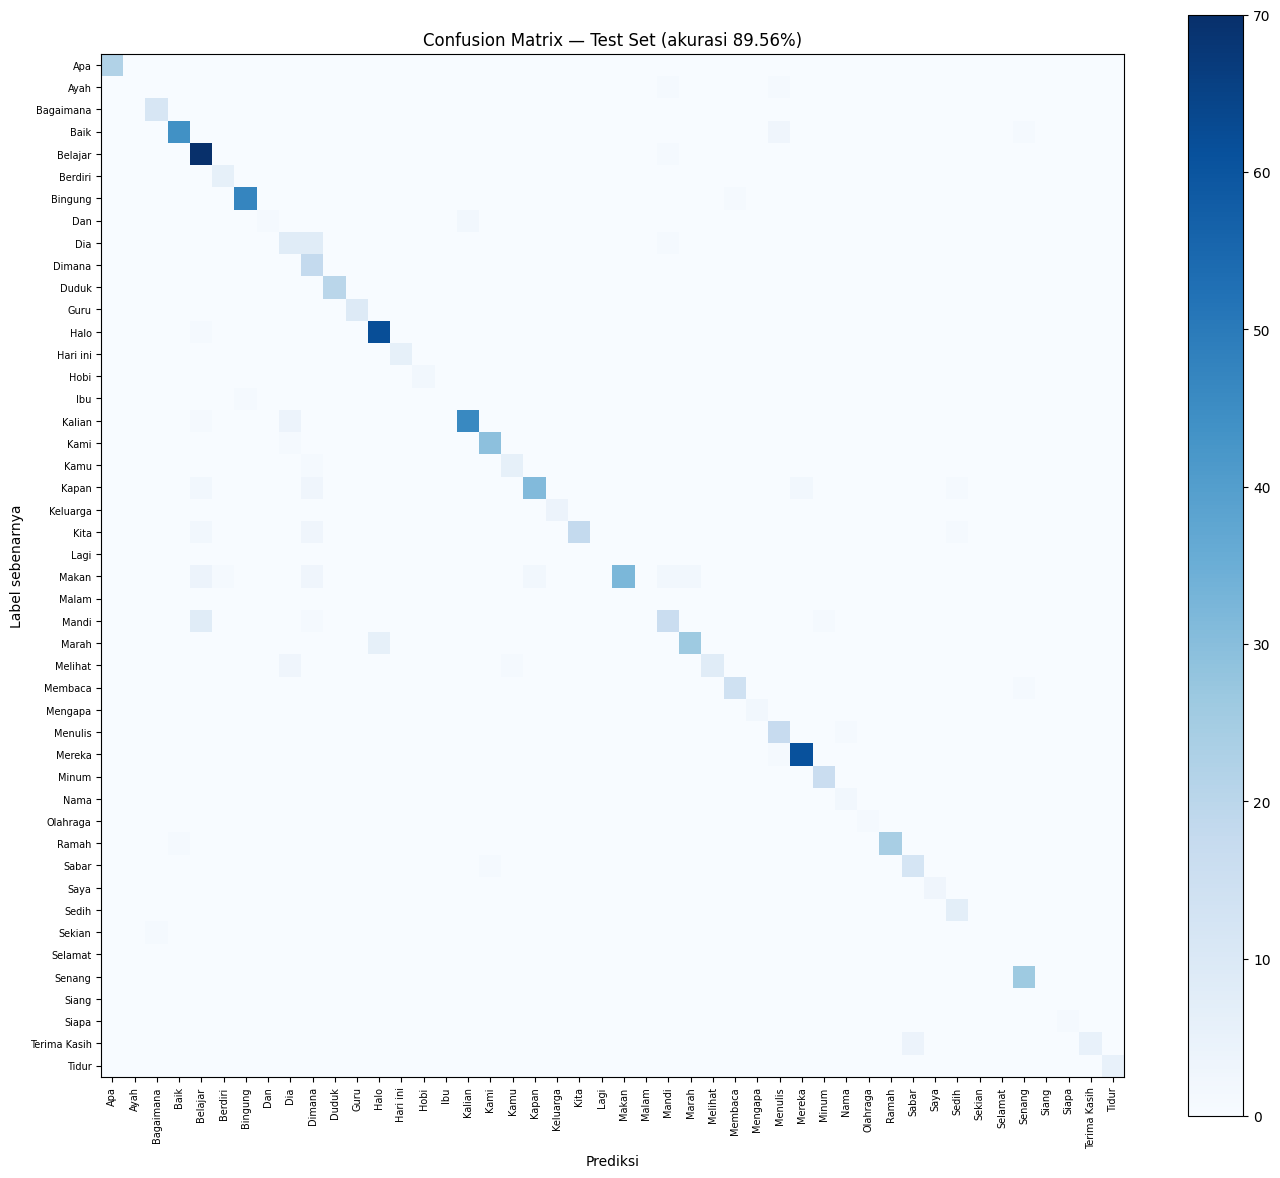


15 kesalahan paling sering (asli -> diprediksi):
  Mandi           -> Belajar         : 8 sequence
  Dia             -> Dimana          : 8 sequence
  Marah           -> Halo            : 6 sequence
  Terima Kasih    -> Sabar           : 4 sequence
  Makan           -> Belajar         : 4 sequence
  Kalian          -> Dia             : 4 sequence
  Melihat         -> Dia             : 3 sequence
  Makan           -> Dimana          : 3 sequence
  Kita            -> Dimana          : 3 sequence
  Kapan           -> Dimana          : 3 sequence
  Baik            -> Menulis         : 3 sequence
  Makan           -> Marah           : 2 sequence
  Makan           -> Mandi           : 2 sequence
  Makan           -> Kapan           : 2 sequence
  Kita            -> Belajar         : 2 sequence

10 kata dengan akurasi terendah (prioritas penambahan dataset):
  Ayah           :   0.0%  (n=2)
  Ibu            :   0.0%  (n=1)
  Malam          :   0.0%  (n=0)
  Lagi           :   0.0%  (n=0)
  S

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_t.numpy(), predictions, labels=list(range(len(le.classes_))))

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(le.classes_)))
ax.set_yticks(range(len(le.classes_)))
ax.set_xticklabels(le.classes_, rotation=90, fontsize=7)
ax.set_yticklabels(le.classes_, fontsize=7)
ax.set_xlabel("Prediksi")
ax.set_ylabel("Label sebenarnya")
ax.set_title(f"Confusion Matrix — Test Set (akurasi {test_acc*100:.2f}%)")
fig.colorbar(im)
plt.tight_layout()
plt.savefig("/content/confusion_matrix.png", dpi=150)
plt.show()

# Pasangan kata yang paling sering tertukar
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)
pairs = []
for i in range(len(le.classes_)):
    for j in range(len(le.classes_)):
        if cm_off[i, j] > 0:
            pairs.append((cm_off[i, j], le.classes_[i], le.classes_[j]))
pairs.sort(reverse=True)

print("\n15 kesalahan paling sering (asli -> diprediksi):")
for n, asli, pred in pairs[:15]:
    print(f"  {asli:<15} -> {pred:<15} : {n} sequence")

# Akurasi per kelas — kata dengan skor terendah = prioritas dataset SignHub
per_class_acc = cm.diagonal() / np.maximum(cm.sum(axis=1), 1)
urut = np.argsort(per_class_acc)
print("\n10 kata dengan akurasi terendah (prioritas penambahan dataset):")
for idx in urut[:10]:
    print(f"  {le.classes_[idx]:<15}: {per_class_acc[idx]*100:5.1f}%  (n={cm.sum(axis=1)[idx]})")

import shutil
shutil.copy("/content/confusion_matrix.png", "/content/drive/MyDrive/IsyaraLive_letterbox/confusion_matrix.png")
print("\n✅ confusion_matrix.png tersimpan di Drive")

## 7c. Uji kompatibilitas dengan backend (WAJIB sebelum copy ke server)
Cell ini memuat ulang checkpoint **persis seperti cara backend memuatnya**. Kalau cell ini lolos, `lstm_model.pt` dijamin bisa dipakai FastAPI. Kalau gagal di sini, backend TIDAK akan error — ia diam-diam masuk dummy mode dan aplikasi mengembalikan `MODEL_BELUM_DILOAD`.

In [17]:
import torch, pickle, json, numpy as np

with open("/content/label_encoder.pkl", "rb") as f:
    le_check = pickle.load(f)
with open("/content/model_config.json") as f:
    cfg = json.load(f)

state = torch.load("/content/lstm_model.pt", map_location="cpu")

# Arsitektur direkonstruksi dari checkpoint, sama seperti detector.py versi baru
hidden_from_ckpt = state["lstm.weight_hh_l0"].shape[1]
classes_from_ckpt = state["classifier.3.weight"].shape[0]
layers_from_ckpt = len({k.split("_l")[-1] for k in state if k.startswith("lstm.weight_ih_l")})

print(f"hidden_size dari checkpoint : {hidden_from_ckpt}  (config: {cfg['hidden_size']})")
print(f"num_layers  dari checkpoint : {layers_from_ckpt}  (config: {cfg['num_layers']})")
print(f"num_classes dari checkpoint : {classes_from_ckpt}  (label encoder: {len(le_check.classes_)})")

assert hidden_from_ckpt == cfg["hidden_size"], "hidden_size checkpoint != config"
assert classes_from_ckpt == len(le_check.classes_), "Jumlah kelas checkpoint != label_encoder.pkl"

check_model = GestureLSTM(num_classes=classes_from_ckpt)
check_model.load_state_dict(state)   # ini yang gagal kalau arsitektur beda
check_model.eval()

# Uji inferensi dengan input dummy berbentuk (1, 15, 63)
dummy = torch.randn(1, 15, 63)
with torch.no_grad():
    out = check_model(dummy)
    prob = torch.softmax(out, dim=1)
print(f"\nOutput shape: {tuple(out.shape)} | jumlah probabilitas: {prob.sum().item():.4f}")

print("\n✅ LOLOS — checkpoint kompatibel dengan backend.")
print("Copy 3 file ini ke folder models/ di backend:")
print("   lstm_model.pt, label_encoder.pkl, model_config.json")

hidden_size dari checkpoint : 128  (config: 128)
num_layers  dari checkpoint : 2  (config: 2)
num_classes dari checkpoint : 46  (label encoder: 46)

Output shape: (1, 46) | jumlah probabilitas: 1.0000

✅ LOLOS — checkpoint kompatibel dengan backend.
Copy 3 file ini ke folder models/ di backend:
   lstm_model.pt, label_encoder.pkl, model_config.json


In [18]:
import numpy as np
from collections import Counter
video_per_word = {}
for w, vid in zip(labels, video_ids):
    video_per_word.setdefault(w, set()).add(vid)

for w in ['Guru', 'Ibu', 'Pagi', 'Selamat', 'Asal', 'Teman', 'Anak', 'Siang', 'Sekian', 'Nama']:
    print(f"{w}: {len(video_per_word.get(w, []))} video unik")

Guru: 14 video unik
Ibu: 9 video unik
Pagi: 0 video unik
Selamat: 2 video unik
Asal: 0 video unik
Teman: 0 video unik
Anak: 0 video unik
Siang: 4 video unik
Sekian: 2 video unik
Nama: 6 video unik


## 8. Leave-One-Subject-Out pada data `aridone` (pakai landmark ternormalisasi)
Latih tanpa 1 subjek sama sekali, uji khusus di subjek itu — bukti generalisasi lintas-penutur paling ketat untuk proposal.

In [19]:
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader

try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

X_all = X_norm  # PENTING: landmark yang sudah dinormalisasi
y_all = np.array(labels)
subj_all = np.array(subject_ids)

print("Ada NaN di data landmark?", np.isnan(X_all.astype(np.float32)).any())

aridone_subjects = sorted({s for s in subj_all if "subjek" in s.lower()})
print(f"Subjek aridone yang tersedia: {aridone_subjects}\n")

results = {}
for held_out_subject in aridone_subjects:
    print(f"=== Held-out: {held_out_subject} ===")
    train_mask = subj_all != held_out_subject
    test_mask  = subj_all == held_out_subject

    Xtr, ytr = X_all[train_mask], y_all[train_mask]
    Xte, yte = X_all[test_mask],  y_all[test_mask]
    if len(Xte) == 0:
        print("  (kosong, skip)\n")
        continue

    ytr_enc = le.transform(ytr)
    yte_enc = le.transform(yte)

    Xtr_t = torch.FloatTensor(Xtr)
    ytr_t = torch.LongTensor(ytr_enc)
    Xte_t = torch.FloatTensor(Xte)
    yte_t = torch.LongTensor(yte_enc)

    loso_model = GestureLSTM(num_classes=len(le.classes_))
    optimizer = torch.optim.Adam(loso_model.parameters(), lr=0.001, weight_decay=1e-4)
    criterion = torch.nn.CrossEntropyLoss()
    loader = DataLoader(TensorDataset(Xtr_t, ytr_t), batch_size=32, shuffle=True)

    loso_model.train()
    nan_detected = False
    for epoch in tqdm(range(40), desc=f"Training (held-out {held_out_subject})"):
        total_loss = 0
        for Xb, yb in loader:
            optimizer.zero_grad()
            loss = criterion(loso_model(Xb), yb)
            if torch.isnan(loss):
                nan_detected = True
                break
            loss.backward()
            torch.nn.utils.clip_grad_norm_(loso_model.parameters(), max_norm=5.0)
            optimizer.step()
            total_loss += loss.item()
        if nan_detected:
            print(f"  ⚠️ Loss jadi NaN di epoch {epoch+1}, training dihentikan!")
            break
        if (epoch + 1) % 10 == 0:
            print(f"  epoch {epoch+1}: avg loss = {total_loss/len(loader):.4f}")

    loso_model.eval()
    with torch.no_grad():
        pred = loso_model(Xte_t).argmax(dim=1)
        acc = (pred == yte_t).float().mean().item()

    unique_pred = np.unique(pred.numpy())
    print(f"  Jumlah kelas unik yang diprediksi: {len(unique_pred)} dari {len(le.classes_)} total kelas")
    if len(unique_pred) <= 2:
        print(f"  ⚠️ Model collapse! Prediksi didominasi kelas: {le.inverse_transform(unique_pred)}")

    results[held_out_subject] = acc
    print(f"  Held-out {held_out_subject}: akurasi {acc*100:.1f}% (n={len(Xte)} sequence)\n")

if results:
    avg_acc = sum(results.values()) / len(results)
    print(f"\n🎯 Rata-rata akurasi leave-one-subject-out: {avg_acc*100:.1f}%")

Ada NaN di data landmark? False
Subjek aridone yang tersedia: [np.str_('aridone-subjek 1'), np.str_('aridone-subjek 2'), np.str_('aridone-subjek 3'), np.str_('aridone-subjek 4'), np.str_('aridone-subjek 5')]

=== Held-out: aridone-subjek 1 ===


Training (held-out aridone-subjek 1):   0%|          | 0/40 [00:00<?, ?it/s]

  epoch 10: avg loss = 0.2307
  epoch 20: avg loss = 0.1167
  epoch 30: avg loss = 0.0900
  epoch 40: avg loss = 0.0874
  Jumlah kelas unik yang diprediksi: 30 dari 46 total kelas
  Held-out aridone-subjek 1: akurasi 65.8% (n=1362 sequence)

=== Held-out: aridone-subjek 2 ===


Training (held-out aridone-subjek 2):   0%|          | 0/40 [00:00<?, ?it/s]

  epoch 10: avg loss = 0.2883
  epoch 20: avg loss = 0.1410
  epoch 30: avg loss = 0.0879
  epoch 40: avg loss = 0.0654
  Jumlah kelas unik yang diprediksi: 28 dari 46 total kelas
  Held-out aridone-subjek 2: akurasi 77.4% (n=270 sequence)

=== Held-out: aridone-subjek 3 ===


...

  epoch 10: avg loss = 0.2623
  epoch 20: avg loss = 0.1716
  epoch 30: avg loss = 0.0961
  epoch 40: avg loss = 0.0776
  Jumlah kelas unik yang diprediksi: 37 dari 46 total kelas
  Held-out aridone-subjek 3: akurasi 74.9% (n=940 sequence)

=== Held-out: aridone-subjek 4 ===


Training (held-out aridone-subjek 4):   0%|          | 0/40 [00:00<?, ?it/s]

  epoch 10: avg loss = 0.2782
  epoch 20: avg loss = 0.1455
  epoch 30: avg loss = 0.1373
  epoch 40: avg loss = 0.0991
  Jumlah kelas unik yang diprediksi: 37 dari 46 total kelas
  Held-out aridone-subjek 4: akurasi 78.6% (n=1234 sequence)

=== Held-out: aridone-subjek 5 ===


Training (held-out aridone-subjek 5):   0%|          | 0/40 [00:00<?, ?it/s]

  epoch 10: avg loss = 0.2668
  epoch 20: avg loss = 0.1125
  epoch 30: avg loss = 0.0701
  epoch 40: avg loss = 0.0869
  Jumlah kelas unik yang diprediksi: 32 dari 46 total kelas
  Held-out aridone-subjek 5: akurasi 68.8% (n=475 sequence)


🎯 Rata-rata akurasi leave-one-subject-out: 73.1%


LOSO + Mirroring

In [20]:
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader

try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

def mirror_sequence(seq):
    """seq: (15, 63) landmark ternormalisasi -> versi mirror (flip sumbu x).
    Merepresentasikan gestur yang sama seolah dilakukan dgn orientasi/tangan berlawanan."""
    pts = seq.reshape(15, 21, 3).copy()
    pts[:, :, 0] = -pts[:, :, 0]  # flip koordinat x
    return pts.reshape(15, 63)

USE_MIRROR_AUGMENTATION = True  # ganti False untuk bandingkan tanpa augmentasi

X_all = X_norm
y_all = np.array(labels)
subj_all = np.array(subject_ids)

print("Ada NaN di data landmark?", np.isnan(X_all.astype(np.float32)).any())

aridone_subjects = sorted({s for s in subj_all if "subjek" in s.lower()})
print(f"Subjek aridone yang tersedia: {aridone_subjects}")
print(f"Mirroring augmentation: {'AKTIF' if USE_MIRROR_AUGMENTATION else 'NONAKTIF'}\n")

results = {}
for held_out_subject in aridone_subjects:
    print(f"=== Held-out: {held_out_subject} ===")
    train_mask = subj_all != held_out_subject
    test_mask  = subj_all == held_out_subject

    Xtr, ytr = X_all[train_mask], y_all[train_mask]
    Xte, yte = X_all[test_mask],  y_all[test_mask]
    if len(Xte) == 0:
        print("  (kosong, skip)\n")
        continue

    if USE_MIRROR_AUGMENTATION:
        Xtr_mirror = np.array([mirror_sequence(s) for s in Xtr], dtype=np.float32)
        Xtr = np.concatenate([Xtr, Xtr_mirror], axis=0)
        ytr = np.concatenate([ytr, ytr], axis=0)  # label sama, cuma datanya digandakan (mirror)
        print(f"  Data training setelah augmentasi: {len(Xtr)} (dari {len(Xtr)//2} asli)")

    ytr_enc = le.transform(ytr)
    yte_enc = le.transform(yte)

    Xtr_t = torch.FloatTensor(Xtr)
    ytr_t = torch.LongTensor(ytr_enc)
    Xte_t = torch.FloatTensor(Xte)
    yte_t = torch.LongTensor(yte_enc)

    loso_model = GestureLSTM(num_classes=len(le.classes_))
    optimizer = torch.optim.Adam(loso_model.parameters(), lr=0.001, weight_decay=1e-4)
    criterion = torch.nn.CrossEntropyLoss()
    loader = DataLoader(TensorDataset(Xtr_t, ytr_t), batch_size=32, shuffle=True)

    loso_model.train()
    nan_detected = False
    for epoch in tqdm(range(40), desc=f"Training (held-out {held_out_subject})"):
        total_loss = 0
        for Xb, yb in loader:
            optimizer.zero_grad()
            loss = criterion(loso_model(Xb), yb)
            if torch.isnan(loss):
                nan_detected = True
                break
            loss.backward()
            torch.nn.utils.clip_grad_norm_(loso_model.parameters(), max_norm=5.0)
            optimizer.step()
            total_loss += loss.item()
        if nan_detected:
            print(f"  ⚠️ Loss jadi NaN di epoch {epoch+1}, training dihentikan!")
            break
        if (epoch + 1) % 10 == 0:
            print(f"  epoch {epoch+1}: avg loss = {total_loss/len(loader):.4f}")

    loso_model.eval()
    with torch.no_grad():
        pred = loso_model(Xte_t).argmax(dim=1)
        acc = (pred == yte_t).float().mean().item()

    unique_pred = np.unique(pred.numpy())
    print(f"  Jumlah kelas unik yang diprediksi: {len(unique_pred)} dari {len(le.classes_)} total kelas")
    if len(unique_pred) <= 2:
        print(f"  ⚠️ Model collapse! Prediksi didominasi kelas: {le.inverse_transform(unique_pred)}")

    results[held_out_subject] = acc
    print(f"  Held-out {held_out_subject}: akurasi {acc*100:.1f}% (n={len(Xte)} sequence)\n")

if results:
    avg_acc = sum(results.values()) / len(results)
    print(f"\n🎯 Rata-rata akurasi leave-one-subject-out (mirror={'ON' if USE_MIRROR_AUGMENTATION else 'OFF'}): {avg_acc*100:.1f}%")

Ada NaN di data landmark? False
Subjek aridone yang tersedia: [np.str_('aridone-subjek 1'), np.str_('aridone-subjek 2'), np.str_('aridone-subjek 3'), np.str_('aridone-subjek 4'), np.str_('aridone-subjek 5')]
Mirroring augmentation: AKTIF

=== Held-out: aridone-subjek 1 ===
  Data training setelah augmentasi: 8184 (dari 4092 asli)


Training (held-out aridone-subjek 1):   0%|          | 0/40 [00:00<?, ?it/s]

  epoch 10: avg loss = 0.1669
  epoch 20: avg loss = 0.0669
  epoch 30: avg loss = 0.0790
  epoch 40: avg loss = 0.0448
  Jumlah kelas unik yang diprediksi: 33 dari 46 total kelas
  Held-out aridone-subjek 1: akurasi 61.5% (n=1362 sequence)

=== Held-out: aridone-subjek 2 ===
  Data training setelah augmentasi: 10368 (dari 5184 asli)


Training (held-out aridone-subjek 2):   0%|          | 0/40 [00:00<?, ?it/s]

  epoch 10: avg loss = 0.2305
  epoch 20: avg loss = 0.1232
  epoch 30: avg loss = 0.0731
  epoch 40: avg loss = 0.0588
  Jumlah kelas unik yang diprediksi: 29 dari 46 total kelas
  Held-out aridone-subjek 2: akurasi 71.1% (n=270 sequence)

=== Held-out: aridone-subjek 3 ===
  Data training setelah augmentasi: 9028 (dari 4514 asli)


...

  epoch 10: avg loss = 0.2151
  epoch 20: avg loss = 0.1353
  epoch 30: avg loss = 0.0795
  epoch 40: avg loss = 0.0674
  Jumlah kelas unik yang diprediksi: 33 dari 46 total kelas
  Held-out aridone-subjek 3: akurasi 72.7% (n=940 sequence)

=== Held-out: aridone-subjek 4 ===
  Data training setelah augmentasi: 8440 (dari 4220 asli)


Training (held-out aridone-subjek 4):   0%|          | 0/40 [00:00<?, ?it/s]

  epoch 10: avg loss = 0.2426
  epoch 20: avg loss = 0.1351
  epoch 30: avg loss = 0.0884
  epoch 40: avg loss = 0.0643
  Jumlah kelas unik yang diprediksi: 33 dari 46 total kelas
  Held-out aridone-subjek 4: akurasi 71.6% (n=1234 sequence)

=== Held-out: aridone-subjek 5 ===
  Data training setelah augmentasi: 9958 (dari 4979 asli)


Training (held-out aridone-subjek 5):   0%|          | 0/40 [00:00<?, ?it/s]

  epoch 10: avg loss = 0.1930
  epoch 20: avg loss = 0.0983
  epoch 30: avg loss = 0.0854
  epoch 40: avg loss = 0.0635
  Jumlah kelas unik yang diprediksi: 31 dari 46 total kelas
  Held-out aridone-subjek 5: akurasi 73.5% (n=475 sequence)


🎯 Rata-rata akurasi leave-one-subject-out (mirror=ON): 70.1%
